In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import json, pickle, itertools
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import binomtest
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, balanced_accuracy_score

PROJECT_DIR = Path('/content/drive/MyDrive/Indian_Food_Research')
RESULTS_DIR = PROJECT_DIR / 'results'
OUT_DIR     = RESULTS_DIR / 'multiseed'
TABLES_DIR  = RESULTS_DIR / 'revision_tables'; TABLES_DIR.mkdir(parents=True, exist_ok=True)
SPLITS_DIR  = PROJECT_DIR / 'splits'
NUM_CLASSES = 100
ORDER  = ['resnet50_scratch', 'linear_probe', 'lora', 'full_finetune']
NICE   = {'resnet50_scratch': 'ResNet-50 (scratch)', 'linear_probe': 'DINOv2 linear probe',
          'lora': 'DINOv2 + LoRA (r=8)', 'full_finetune': 'DINOv2 full fine-tuning'}
class_names = pd.read_csv(PROJECT_DIR / 'reports' / 'class_names.csv')['Class'].tolist()
test_idx = pickle.load(open(SPLITS_DIR / 'test_idx.pkl', 'rb'))

runs = []
for f in sorted(OUT_DIR.glob('*.npz')):
    z = np.load(f, allow_pickle=False)
    meta = json.loads(str(z['meta']))
    runs.append({**meta, 'pred': z['test_pred'], 'true': z['test_true']})

y05_path = RESULTS_DIR / 'test_labels.npy'
nb05 = {'resnet50_scratch': 'preds_ResNet50_scratch.npy',
        'linear_probe':     'preds_DINOv2__Linear_Probe.npy',
        'full_finetune':    'preds_DINOv2__Full_FT.npy',
        'lora':             'preds_DINOv2__LoRA_r=8.npy'}
have = {r['method'] for r in runs}
if y05_path.exists():
    y05 = np.load(y05_path)
    if runs and not np.array_equal(y05, runs[0]['true']):
        print('WARNING: notebook 05 test labels differ in order from notebook 07 - fallback rows skipped')
    else:
        for m, fn in nb05.items():
            if m not in have and (RESULTS_DIR / fn).exists():
                runs.append(dict(method=m, fraction=1.0, seed=-1, pred=np.load(RESULTS_DIR / fn), true=y05))
                print('single-run fallback from notebook 05:', m)
assert runs, 'no runs found - run notebook 07 or check notebook 05 prediction files'
R = pd.DataFrame(runs)
print(R.groupby(['method', 'fraction']).seed.apply(lambda s: sorted(s.tolist())).to_string())
print('seed = -1 means one run from notebook 05 (single run, descriptive only)')

method            fraction
full_finetune     0.10        [0, 1, 2]
                  0.25        [0, 1, 2]
                  0.50        [0, 1, 2]
                  1.00        [0, 1, 2]
linear_probe      0.10        [0, 1, 2]
                  0.25        [0, 1, 2]
                  0.50        [0, 1, 2]
                  1.00        [0, 1, 2]
lora              0.10        [0, 1, 2]
                  0.25        [0, 1, 2]
                  0.50        [0, 1, 2]
                  1.00        [0, 1, 2]
lora_r16          1.00        [0, 1, 2]
lora_r4           1.00        [0, 1, 2]
resnet50_scratch  0.10        [0, 1, 2]
                  0.25        [0, 1, 2]
                  0.50        [0, 1, 2]
                  1.00        [0, 1, 2]
seed = -1 means one run from notebook 05 (single run, descriptive only)


In [ ]:
def metrics(y, p):
    P, Rc, F1, _ = precision_recall_fscore_support(y, p, labels=range(NUM_CLASSES), average='macro', zero_division=0)
    return dict(top1=accuracy_score(y, p), macro_precision=P, macro_recall=Rc, macro_f1=F1,
                balanced_acc=balanced_accuracy_score(y, p))

M = pd.DataFrame([{'method': r.method, 'fraction': r.fraction, 'seed': r.seed, **metrics(r.true, r.pred)}
                  for r in R.itertuples()])
M.to_csv(TABLES_DIR / 'metrics_per_run.csv', index=False)

COLS = ['top1', 'macro_precision', 'macro_recall', 'macro_f1', 'balanced_acc']
def mean_sd_table(frac):
    rows = []
    for m in ORDER:
        g = M[(M.method == m) & (M.fraction == frac)]
        if g.empty: continue
        row = {'Method': NICE[m], 'n seeds': len(g)}
        for c in COLS:
            row[c] = f"{100*g[c].mean():.2f} ± {100*g[c].std(ddof=1):.2f}" if len(g) > 1 else f"{100*g[c].mean():.2f}"
        rows.append(row)
    return pd.DataFrame(rows)

t_full = mean_sd_table(1.0)
t_full.to_csv(TABLES_DIR / 'table_main_100pct_mean_sd.csv', index=False)
t_full

,Method,n seeds,top1,macro_precision,macro_recall,macro_f1,balanced_acc
0,ResNet-50 (scratch),3,63.77 ± 3.04,62.25 ± 2.47,61.79 ± 3.13,60.46 ± 3.00,61.79 ± 3.13
1,DINOv2 linear probe,3,94.15 ± 0.09,94.88 ± 0.71,93.68 ± 0.45,93.78 ± 0.63,93.68 ± 0.45
2,DINOv2 + LoRA (r=8),3,95.92 ± 0.45,94.87 ± 1.19,95.11 ± 0.87,94.67 ± 0.99,95.11 ± 0.87
3,DINOv2 full fine-tuning,3,94.49 ± 1.49,93.69 ± 1.12,93.47 ± 1.46,93.18 ± 1.30,93.47 ± 1.46


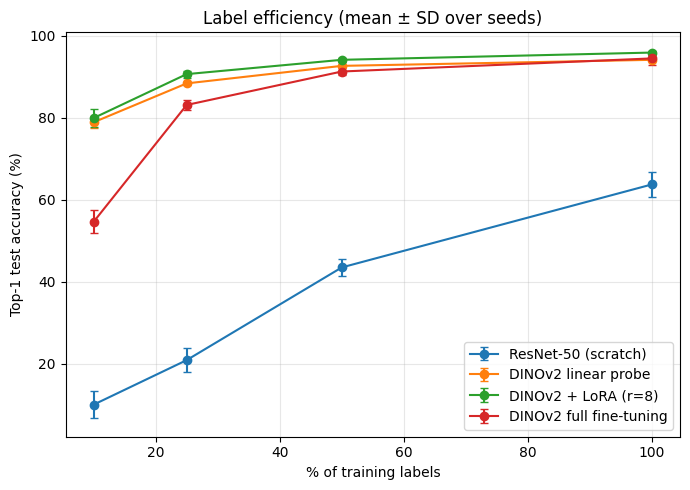

,method,labels_%,n_seeds,top1_mean,top1_sd,macro_f1_mean
0,ResNet-50 (scratch),10.0,3,10.03,3.33,5.25
1,ResNet-50 (scratch),25.0,3,20.89,2.98,14.48
2,ResNet-50 (scratch),50.0,3,43.51,2.17,37.50
3,ResNet-50 (scratch),100.0,3,63.77,3.04,60.46
4,DINOv2 linear probe,10.0,3,78.91,1.42,75.18
5,DINOv2 linear probe,25.0,3,88.40,0.45,86.38
6,DINOv2 linear probe,50.0,3,92.67,0.23,92.13
7,DINOv2 linear probe,100.0,3,94.15,0.09,93.78
8,DINOv2 + LoRA (r=8),10.0,3,79.94,2.18,76.69
9,DINOv2 + LoRA (r=8),25.0,3,90.66,0.84,88.37


In [ ]:
fracs = sorted(M.fraction.unique())
le = []
plt.figure(figsize=(7, 5))
for m in ORDER:
    mu, sd, xs = [], [], []
    for fr in fracs:
        g = M[(M.method == m) & (M.fraction == fr)]
        if g.empty: continue
        xs.append(100 * fr); mu.append(100 * g.top1.mean()); sd.append(100 * g.top1.std(ddof=1) if len(g) > 1 else 0)
        le.append({'method': NICE[m], 'labels_%': 100 * fr, 'n_seeds': len(g), 'top1_mean': mu[-1], 'top1_sd': sd[-1],
                   'macro_f1_mean': 100 * g.macro_f1.mean()})
    if xs: plt.errorbar(xs, mu, yerr=sd, marker='o', capsize=3, label=NICE[m])
plt.xlabel('% of training labels'); plt.ylabel('Top-1 test accuracy (%)'); plt.grid(alpha=.3); plt.legend()
plt.title('Label efficiency (mean ± SD over seeds)'); plt.tight_layout()
plt.savefig(TABLES_DIR / 'label_efficiency_mean_sd.png', dpi=300); plt.show()
pd.DataFrame(le).to_csv(TABLES_DIR / 'label_efficiency_mean_sd.csv', index=False)
pd.DataFrame(le).round(2)

In [ ]:
def per_class_recall(y, p):
    return np.array([(p[y == c] == c).mean() if (y == c).any() else np.nan for c in range(NUM_CLASSES)])

y_ref = R.iloc[0].true
n_test = np.bincount(y_ref, minlength=NUM_CLASSES)
pc = pd.DataFrame({'class': class_names, 'n_test': n_test})
for m in ORDER:
    g = R[(R.method == m) & (R.fraction == 1.0)]
    if g.empty: continue
    rec = np.vstack([per_class_recall(r.true, r.pred) for r in g.itertuples()])
    pc[f'{m}_recall_mean'] = rec.mean(0)
pc.sort_values('n_test').to_csv(TABLES_DIR / 'per_class_recall.csv', index=False)
print('classes with 1 test image :', int((n_test == 1).sum()))
print('classes with <=2 test imgs:', int((n_test <= 2).sum()))
print('test images per class: min', n_test.min(), 'median', int(np.median(n_test)), 'max', n_test.max())
focus = 'lora_recall_mean' if 'lora_recall_mean' in pc else pc.columns[-1]
pc.sort_values(focus).head(15)

classes with 1 test image : 4
classes with <=2 test imgs: 10
test images per class: min 1 median 8 max 12


,class,n_test,resnet50_scratch_recall_mean,linear_probe_recall_mean,lora_recall_mean,full_finetune_recall_mean
25,Dahi_Kadhi,2,0.000000,0.500000,0.166667,0.000000
48,Manchow_soup,2,0.166667,0.500000,0.166667,0.166667
16,Chicken_crispy,7,0.571429,0.571429,0.571429,0.571429
34,Fried_rice,6,0.444444,0.666667,0.666667,0.722222
15,Chicken_biryani,9,0.296296,0.888889,0.777778,0.814815
74,Pulao,9,0.703704,0.777778,0.777778,0.777778
24,Curd_rice,8,0.541667,0.791667,0.791667,0.750000
31,Egg_biryani,7,0.666667,0.761905,0.809524,0.714286
36,Ghevar,6,0.333333,0.833333,0.833333,0.944444
17,Chicken_curry,9,0.444444,0.814815,0.851852,0.851852


In [ ]:
def holm(p):
    p = np.asarray(p, float); m = len(p); order = np.argsort(p); adj = np.empty(m); run = 0.0
    for rank, i in enumerate(order):
        run = max(run, (m - rank) * p[i]); adj[i] = min(1.0, run)
    return adj

sub = R[R.fraction == 1.0]
methods = [m for m in ORDER if m in set(sub.method)]
seeds = sorted(set(sub.seed))
C = {(r.method, r.seed): (r.pred == r.true) for r in sub.itertuples()}

rows = []
for s in seeds:
    block = []
    for a, b in itertools.combinations(methods, 2):
        if (a, s) not in C or (b, s) not in C: continue
        ca, cb = C[a, s], C[b, s]
        n10, n01 = int((ca & ~cb).sum()), int((~ca & cb).sum())
        p = 1.0 if n10 + n01 == 0 else binomtest(n10, n10 + n01, 0.5).pvalue
        block.append({'seed': s, 'A': NICE[a], 'B': NICE[b], 'A only correct': n10, 'B only correct': n01,
                      'delta_pp (A-B)': round(100 * (ca.mean() - cb.mean()), 2), 'p_exact': p})
    if block:
        adj = holm([r['p_exact'] for r in block])
        for r, q in zip(block, adj): r['p_holm'] = q; r['significant@0.05'] = q < 0.05
        rows += block
mcn = pd.DataFrame(rows)
mcn.to_csv(TABLES_DIR / 'mcnemar_per_seed_holm.csv', index=False)
mcn.round(4)

,seed,A,B,A only correct,B only correct,delta_pp (A-B),p_exact,p_holm,significant@0.05
0,0,ResNet-50 (scratch),DINOv2 linear probe,5,234,-33.78,0.0000,0.0000,True
1,0,ResNet-50 (scratch),DINOv2 + LoRA (r=8),1,239,-35.10,0.0000,0.0000,True
2,0,ResNet-50 (scratch),DINOv2 full fine-tuning,2,222,-32.45,0.0000,0.0000,True
3,0,DINOv2 linear probe,DINOv2 + LoRA (r=8),8,17,-1.33,0.1078,0.2155,False
4,0,DINOv2 linear probe,DINOv2 full fine-tuning,21,12,1.33,0.1628,0.2155,False
5,0,DINOv2 + LoRA (r=8),DINOv2 full fine-tuning,19,1,2.65,0.0000,0.0001,True
6,1,ResNet-50 (scratch),DINOv2 linear probe,4,202,-29.20,0.0000,0.0000,True
7,1,ResNet-50 (scratch),DINOv2 + LoRA (r=8),1,212,-31.12,0.0000,0.0000,True
8,1,ResNet-50 (scratch),DINOv2 full fine-tuning,3,209,-30.38,0.0000,0.0000,True
9,1,DINOv2 linear probe,DINOv2 + LoRA (r=8),6,19,-1.92,0.0146,0.0439,True


In [ ]:
rng = np.random.default_rng(0)
B = 10000
boot_rows = []
for a, b in itertools.combinations(methods, 2):
    sa = [C[a, s] for s in seeds if (a, s) in C]; sb = [C[b, s] for s in seeds if (b, s) in C]
    if not sa or not sb: continue
    d = np.mean(sa, 0) - np.mean(sb, 0)
    idx = rng.integers(0, len(d), (B, len(d)))
    bs = d[idx].mean(1)
    lo, hi = np.percentile(bs, [2.5, 97.5])
    boot_rows.append({'A': NICE[a], 'B': NICE[b], 'delta_pp (A-B)': round(100 * d.mean(), 2),
                      '95% CI low': round(100 * lo, 2), '95% CI high': round(100 * hi, 2),
                      'CI excludes 0': bool(lo > 0 or hi < 0)})
boot = pd.DataFrame(boot_rows)
boot.to_csv(TABLES_DIR / 'paired_bootstrap_seed_averaged.csv', index=False)
boot

,A,B,delta_pp (A-B),95% CI low,95% CI high,CI excludes 0
0,ResNet-50 (scratch),DINOv2 linear probe,-30.38,-33.53,-27.34,True
1,ResNet-50 (scratch),DINOv2 + LoRA (r=8),-32.15,-35.25,-29.06,True
2,ResNet-50 (scratch),DINOv2 full fine-tuning,-30.73,-33.73,-27.78,True
3,DINOv2 linear probe,DINOv2 + LoRA (r=8),-1.77,-2.95,-0.64,True
4,DINOv2 linear probe,DINOv2 full fine-tuning,-0.34,-1.62,0.93,False
5,DINOv2 + LoRA (r=8),DINOv2 full fine-tuning,1.43,0.54,2.36,True
